In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8')
print("All libraries loaded!")

All libraries loaded!


In [3]:
df = pd.read_csv('../data/diabetes_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [4]:
# X = everything the model learns from
# y = what the model tries to predict
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:", X.columns.tolist())

Features shape: (768, 8)
Target shape: (768,)

Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training patients:", X_train.shape[0])
print("Testing patients:", X_test.shape[0])

Training patients: 614
Testing patients: 154


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f} ({acc*100:.2f}%)")

Logistic Regression: 0.7662 (76.62%)
Decision Tree: 0.7273 (72.73%)
Random Forest: 0.7662 (76.62%)


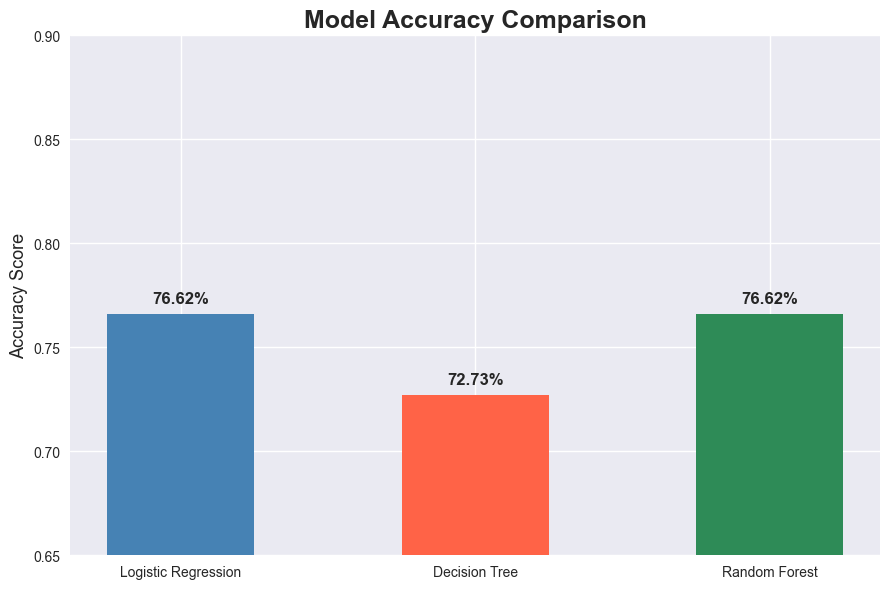

In [8]:
plt.figure(figsize=(9, 6))
bars = plt.bar(results.keys(), results.values(),
               color=['steelblue', 'tomato', 'seagreen'], width=0.5)

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc*100:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=18, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=13)
plt.ylim(0.65, 0.90)
plt.tight_layout()
plt.savefig('../outputs/charts/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Train Random Forest again to get predictions
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("=== Random Forest — Detailed Report ===\n")
print(classification_report(y_test, y_pred_best,
      target_names=['Healthy', 'Diabetic']))

=== Random Forest — Detailed Report ===

              precision    recall  f1-score   support

     Healthy       0.82      0.81      0.82        99
    Diabetic       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



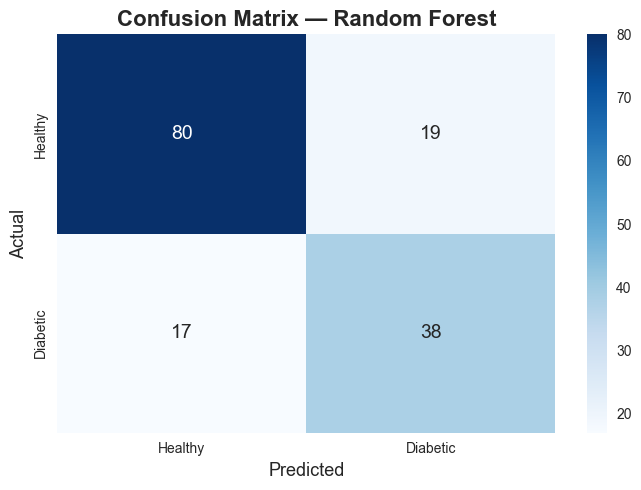

In [10]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Diabetic'],
            yticklabels=['Healthy', 'Diabetic'],
            annot_kws={'size': 14})

plt.title('Confusion Matrix — Random Forest', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Predicted', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/charts/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

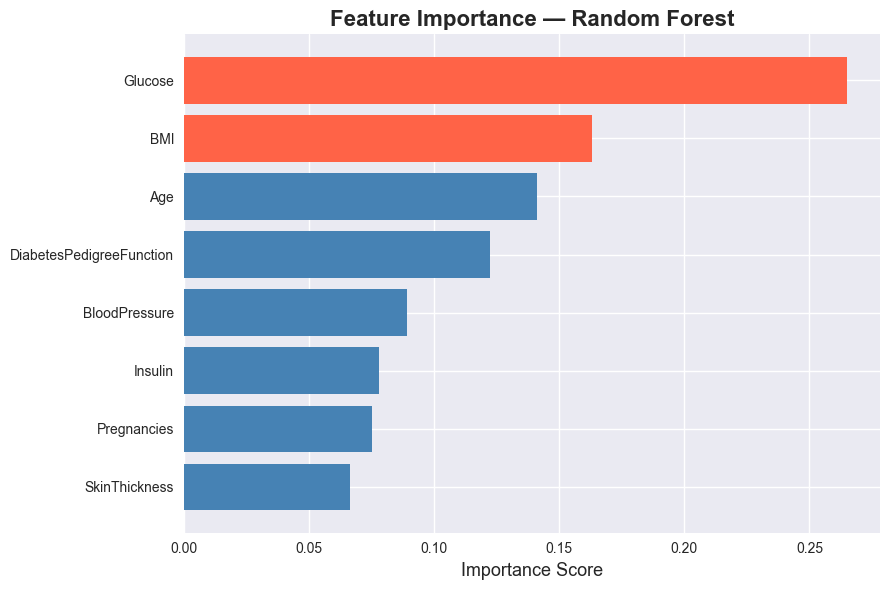

In [11]:
feature_names = df.drop('Outcome', axis=1).columns
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance')

plt.figure(figsize=(9, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color=['tomato' if x > 0.15 else 'steelblue' for x in feat_df['Importance']])
plt.title('Feature Importance — Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/charts/08_feature_importance_ml.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("=" * 45)
print("       DIABETES PREDICTION — SUMMARY")
print("=" * 45)
print(f"\nDataset:      768 patients, 8 features")
print(f"Train size:   {X_train.shape[0]} patients")
print(f"Test size:    {X_test.shape[0]} patients")
print("\nModel Accuracies:")
for name, acc in results.items():
    bar = '█' * int(acc * 30)
    print(f"  {name:<25} {bar} {acc*100:.2f}%")
print(f"\nBest Model:   Random Forest")
print(f"Top Feature:  Glucose (confirmed by both EDA and ML)")
print("=" * 45)

       DIABETES PREDICTION — SUMMARY

Dataset:      768 patients, 8 features
Train size:   614 patients
Test size:    154 patients

Model Accuracies:
  Logistic Regression       ██████████████████████ 76.62%
  Decision Tree             █████████████████████ 72.73%
  Random Forest             ██████████████████████ 76.62%

Best Model:   Random Forest
Top Feature:  Glucose (confirmed by both EDA and ML)


In [16]:
def predict_diabetes(pregnancies, glucose, blood_pressure, 
                     skin_thickness, insulin, bmi, 
                     diabetes_pedigree, age):
    
    feature_names = df.drop('Outcome', axis=1).columns
    patient = pd.DataFrame([[pregnancies, glucose, blood_pressure,
                         skin_thickness, insulin, bmi,
                         diabetes_pedigree, age]], columns=feature_names)
    
    patient_scaled = scaler.transform(patient)
    prediction = best_model.predict(patient_scaled)[0]
    probability = best_model.predict_proba(patient_scaled)[0][1]
    
    print("=" * 40)
    print("       DIABETES RISK ASSESSMENT")
    print("=" * 40)
    print(f"  Glucose:      {glucose}")
    print(f"  BMI:          {bmi}")
    print(f"  Age:          {age}")
    print(f"  Risk Score:   {probability*100:.1f}%")
    print(f"  Result:       {'⚠️  HIGH RISK' if prediction == 1 else '✅ LOW RISK'}")
    print("=" * 40)

# Test it with a real example
predict_diabetes(
    pregnancies=2,
    glucose=138,
    blood_pressure=62,
    skin_thickness=35,
    insulin=0,
    bmi=33.6,
    diabetes_pedigree=0.127,
    age=47
)

predict_diabetes(0, 85, 66, 29, 0, 26.6, 0.351, 24)
predict_diabetes(8, 183, 64, 0, 0, 23.3, 0.672, 32)

       DIABETES RISK ASSESSMENT
  Glucose:      138
  BMI:          33.6
  Age:          47
  Risk Score:   58.0%
  Result:       ⚠️  HIGH RISK
       DIABETES RISK ASSESSMENT
  Glucose:      85
  BMI:          26.6
  Age:          24
  Risk Score:   0.0%
  Result:       ✅ LOW RISK
       DIABETES RISK ASSESSMENT
  Glucose:      183
  BMI:          23.3
  Age:          32
  Risk Score:   56.0%
  Result:       ⚠️  HIGH RISK
